In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from sklearn.datasets import make_classification
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Dummy Dataset

In [3]:
X = np.concat((np.arange(10,20,1).reshape(10,1),np.random.randn(10).reshape(10,1)),axis=1)
y = np.random.randint(0,2,size=(10,))

In [4]:
df = pd.DataFrame(data=X,columns=['X1','X2'])
df['Y'] = y
df

,X1,X2,Y
0,10.0,-0.461952,0
1,11.0,0.283224,0
2,12.0,-0.959683,1
3,13.0,0.597102,1
4,14.0,0.857238,0
5,15.0,0.287894,1
6,16.0,-0.834832,0
7,17.0,0.620186,0
8,18.0,1.120465,1
9,19.0,0.158870,1


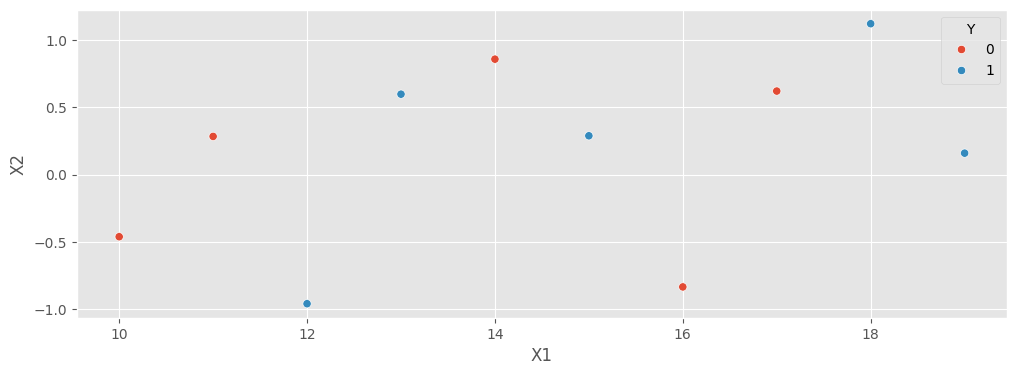

In [5]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x=df.X1,y=df.X2,hue=df.Y)
plt.show()

# Intuition Of Model

## Asign Equal Weight To All The Outputs

In [6]:
df['Weight'] = 1/df.shape[0]
df

,X1,X2,Y,Weight
0,10.0,-0.461952,0,0.1
1,11.0,0.283224,0,0.1
2,12.0,-0.959683,1,0.1
3,13.0,0.597102,1,0.1
4,14.0,0.857238,0,0.1
5,15.0,0.287894,1,0.1
6,16.0,-0.834832,0,0.1
7,17.0,0.620186,0,0.1
8,18.0,1.120465,1,0.1
9,19.0,0.158870,1,0.1


## Train Decision Tree With Max Depth 1

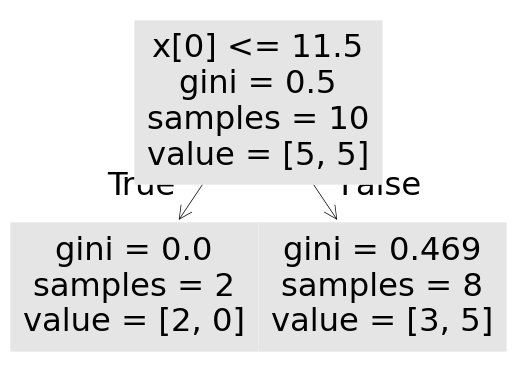

In [7]:
dtree = DecisionTreeClassifier(max_depth=1)
dtree.fit(X,y)
plot_tree(dtree)
plt.show()

## Pridict Based On That Model

In [8]:
y_pred = dtree.predict(X)
df['Y_predicted'] = y_pred
df

,X1,X2,Y,Weight,Y_predicted
0,10.0,-0.461952,0,0.1,0
1,11.0,0.283224,0,0.1,0
2,12.0,-0.959683,1,0.1,1
3,13.0,0.597102,1,0.1,1
4,14.0,0.857238,0,0.1,1
5,15.0,0.287894,1,0.1,1
6,16.0,-0.834832,0,0.1,1
7,17.0,0.620186,0,0.1,1
8,18.0,1.120465,1,0.1,1
9,19.0,0.158870,1,0.1,1


## Update The Weights
- **error = sum of wrongly classified weights**
- **α = 0.5 * log( (1-error)/error )**
- **New_Weight = Old_Weight * e^(α)**

      Where data is incorrectly classified
- **New_Weight = Old_Weight * e^(-α)**

      Where data is correctly classified
- **normality = New_weight / sum(New_weights)**

      To make sum of all weights = 1
- **Weight = normality**

## Why this is done

    To increase the weight of the incorrectly classifired objects

In [9]:
def update_weight(df):
    corr_clf = df[['Y','Weight','Y_predicted']][df['Y'] == df['Y_predicted']]
    incorr_clf = df[['Y','Weight','Y_predicted']][df['Y'] != df['Y_predicted']]
    error = incorr_clf.shape[0]/10

    lambda_ = .5*np.log((1-error)/(error+.00000000001))
    update = np.where(df['Y'] == df['Y_predicted'],df['Weight'] * np.exp(-lambda_),df['Weight'] * np.exp(lambda_))
    df['Weight'] = update/update.sum()

In [10]:
update_weight(df)
df

,X1,X2,Y,Weight,Y_predicted
0,10.0,-0.461952,0,0.071429,0
1,11.0,0.283224,0,0.071429,0
2,12.0,-0.959683,1,0.071429,1
3,13.0,0.597102,1,0.071429,1
4,14.0,0.857238,0,0.166667,1
5,15.0,0.287894,1,0.071429,1
6,16.0,-0.834832,0,0.166667,1
7,17.0,0.620186,0,0.166667,1
8,18.0,1.120465,1,0.071429,1
9,19.0,0.158870,1,0.071429,1


In [11]:
df['Weight'].sum()

np.float64(1.0)

## Declaring Intervals

In [12]:
df['interval_end'] = np.cumsum(df['Weight'])
df['interval_start'] = df['interval_end'].shift(1)
df['interval_start'] = df['interval_start'].fillna(0)
df

,X1,X2,Y,Weight,Y_predicted,interval_end,interval_start
0,10.0,-0.461952,0,0.071429,0,0.071429,0.000000
1,11.0,0.283224,0,0.071429,0,0.142857,0.071429
2,12.0,-0.959683,1,0.071429,1,0.214286,0.142857
3,13.0,0.597102,1,0.071429,1,0.285714,0.214286
4,14.0,0.857238,0,0.166667,1,0.452381,0.285714
5,15.0,0.287894,1,0.071429,1,0.523810,0.452381
6,16.0,-0.834832,0,0.166667,1,0.690476,0.523810
7,17.0,0.620186,0,0.166667,1,0.857143,0.690476
8,18.0,1.120465,1,0.071429,1,0.928571,0.857143
9,19.0,0.158870,1,0.071429,1,1.000000,0.928571


## Random Data Selection Using Intervals

In [13]:
rand_val = np.random.rand(10)
indexs:list = []
for i in rand_val:
    indexs.append(df[(df['interval_start']<=i) & (df['interval_end']>i)].index[0])

In [14]:
df.iloc[indexs]

,X1,X2,Y,Weight,Y_predicted,interval_end,interval_start
6,16.0,-0.834832,0,0.166667,1,0.690476,0.523810
7,17.0,0.620186,0,0.166667,1,0.857143,0.690476
6,16.0,-0.834832,0,0.166667,1,0.690476,0.523810
9,19.0,0.158870,1,0.071429,1,1.000000,0.928571
4,14.0,0.857238,0,0.166667,1,0.452381,0.285714
2,12.0,-0.959683,1,0.071429,1,0.214286,0.142857
0,10.0,-0.461952,0,0.071429,0,0.071429,0.000000
0,10.0,-0.461952,0,0.071429,0,0.071429,0.000000
2,12.0,-0.959683,1,0.071429,1,0.214286,0.142857
9,19.0,0.158870,1,0.071429,1,1.000000,0.928571


# My Dodel

In [15]:
class AdaBoost:
    def __init__(self,n_estimaters=100):
        self.models:dict = {}
        self.n_estimaters=n_estimaters

    def fit(self, X_train=None, y_train=None):

        rows = y_train.shape[0]
        
        data = np.concat((y_train.reshape(rows,1),np.full((rows,1),1/rows)), axis=1)
        
        from sklearn.tree import DecisionTreeClassifier
        self.models['model_0'] = [DecisionTreeClassifier(max_depth=1)]
        self.models['model_0'][0].fit(X_train,y_train)
        
        y_pred = self.models['model_0'][0].predict(X_train)
        data = np.concat((data,y_pred.reshape(rows,1)),axis=1)

        data = self.update_weight(data,epoch=0)
        
        data = np.concat((data,np.cumsum(data[:,1]).reshape(rows,1)), axis=1)
        intv_start = np.roll(data[:,3],1)
        intv_start[0] = 0
        data = np.concat((data,intv_start.reshape(rows,1)), axis=1)

        rand_val = np.random.rand(rows)
        indexs:list = []
        for i in rand_val:
            indexs.append(np.where( (data[:,4]<=i) & (data[:,3]>i) )[0][0])

        for i in range(1,self.n_estimaters):
            X_train,y_train = X_train[indexs],y_train[indexs]
            data = data[indexs]
            data[:,1] = np.full((rows,1),1/rows).reshape(rows,)
            self.models[f'model_{i}'] = [DecisionTreeClassifier(max_depth=1)]
            self.models[f'model_{i}'][0].fit(X_train,y_train)
            
            y_pred = self.models[f'model_{i}'][0].predict(X_train)
            data[:,2] = y_pred.ravel()
    
            data = self.update_weight(data,epoch=i)
            
            data[:,3] = np.cumsum(data[:,1]).ravel()
            intv_start = np.roll(data[:,3],1)
            intv_start[0] = 0
            data[:,4] = intv_start.ravel()
    
            rand_val = np.random.rand(rows)
            indexs:list = []
            for i in rand_val:
                indexs.append(np.where( (data[:,4]<=i) & (data[:,3]>i) )[0][0])

                
    def update_weight(self, data, epoch):
        corr_clf = data[np.where(data[:,0] == data[:,2])]
        incorr_clf = data[np.where(data[:,0] != data[:,2])]
        error = incorr_clf[:,1].sum()
    
        lambda_ = .5*np.log((1-error)/(error+.00000000001))
        self.models[f'model_{epoch}'].append(lambda_)
        update = np.where(data[:,0] == data[:,2],data[:,1] * np.exp(-lambda_),data[:,1] * np.exp(lambda_))
        data[:,1] = update/update.sum()
        return data

    def predict(self, X_test):
        models_output = []
        for key in self.models:
            pred = self.models[key][0].predict(X_test)
            pred[pred == 0] = - 1
            models_output.append(pred * self.models[key][1])
        my_pred = np.sign(np.sum(models_output,axis=0))
        my_pred[my_pred == -1] = 0
        return my_pred

In [16]:
my = AdaBoost(n_estimaters=100)
my.fit(X,y)
my.predict([[12.0, -0.553621], [13.0, -0.390719]])

array([0., 0.])

In [17]:
ada_clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=10)
ada_clf.fit(X,y)
ada_clf.predict([[12.0, -0.553621], [13.0, -0.390719]])

array([1, 1])

# Comparison With Sklearn Model

In [18]:
from sklearn.datasets import load_breast_cancer

In [19]:
t,c = load_breast_cancer(return_X_y=True)

In [20]:
my = AdaBoost(n_estimaters=1)
my.fit(t,c)
my_pred = my.predict(t)
accuracy_score(y_pred=my_pred,y_true=c)

0.9226713532513181

In [21]:
ada_clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100)
ada_clf.fit(t,c)
ada_predict = ada_clf.predict(t)
accuracy_score(y_pred=ada_predict,y_true=c)
# ada_predict.shape, c.shape

1.0